In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Campione caricato (BIS): 1,174,592 righe
Righe senza corrispondenza comunale: 0 su 1174592
   Comune_Codice    Region Gender  Age Education_Macro  Total_Gross_Income  \
0           1001  Piemonte      M   37         1_Medio        23527.104518   
1           1001  Piemonte      M   85          0_Base         1537.352795   
2           1001  Piemonte      M   84          0_Base        21393.717251   
3           1001  Piemonte      M   62          2_Alto        73219.716790   
4           1001  Piemonte      F   58          2_Alto        84828.509990   

   Numero_contribuenti       r_i  
0                 1963  0.002732  
1                 1963  0.006757  
2                 1963  0.006757  
3                 1963  0.012500  
4                 1963  0.007353  

Distribuzione r_i (BIS):
count    1.174592e+06
mean     2.520394e-02
std      9.145392e-02
min      2.043728e-06
25%      1.355014e-03
50%      3.649635e-03
75%      1.000000e-02
max      1.000000e+00
Name: r_i, dtype: float64
Ca

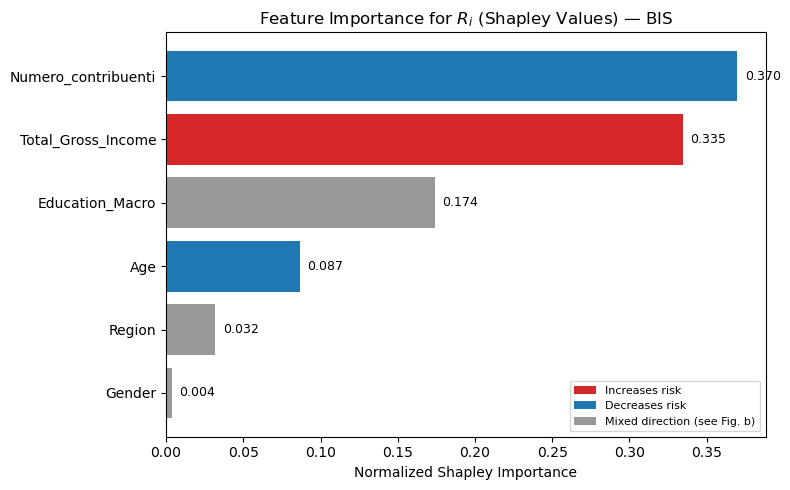

✅ Grafico 1 (BIS) salvato


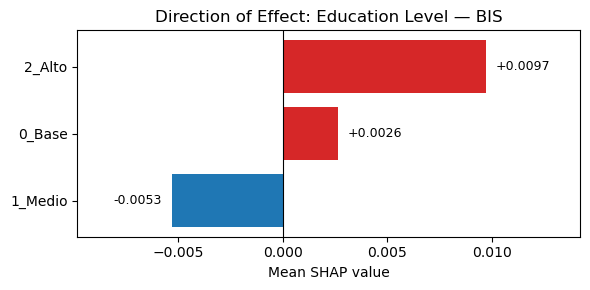

✅ Grafico 2 (BIS) salvato


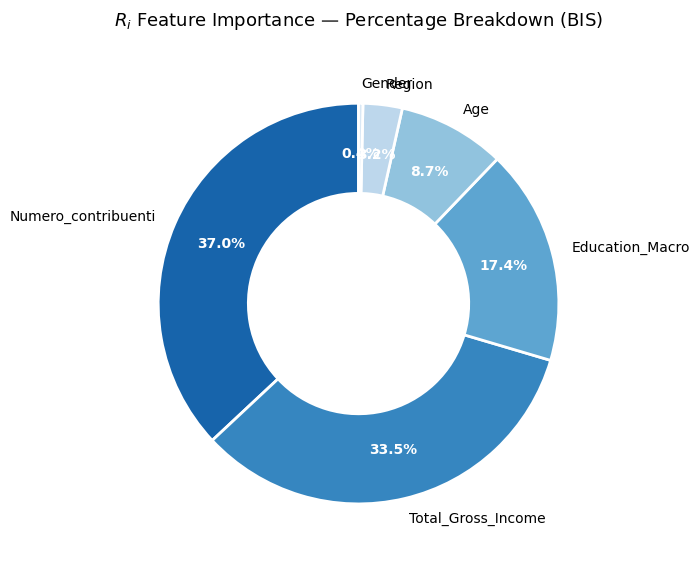

✅ Grafico comunicativo (torta) salvato: ./Materiale/shapley_percentuali_torta_BIS.pdf

Tabella percentuali pronta per il testo:
               feature  percentuale
0  Numero_contribuenti         37.0
1   Total_Gross_Income         33.5
2      Education_Macro         17.4
3                  Age          8.7
4               Region          3.2
5               Gender          0.4
R² del modello di validazione (BIS): 0.6628

RGA (BIS): 0.9826

RGE (BIS):
                          RGE
Numero_contribuenti  0.264835
Total_Gross_Income   0.128925
Education_Macro      0.032091
Age                  0.021140
Region               0.000866
Gender               0.000116

RGF (BIS): The RGA-based imparity between the protected gorups is 0.0012576705993401216.

RGR (BIS):
                          RGR
Gender               0.999973
Region               0.999650
Age                  0.986932
Education_Macro      0.986884
Total_Gross_Income   0.970750
Numero_contribuenti  0.700044

✅ Validazione SAFE AI 

In [1]:
# %% CELL 1 — Installazione pacchetti + caricamento dati
# =============================================================================
#!pip install safeaipackage shap catboost xgboost -q

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# CAMBIATO: campione BIS (istruzione condizionata età/genere), da 02BIS
PATH_CAMPIONE = './Materiale/campione_individuale_r_i_BIS.csv'
df = pd.read_csv(PATH_CAMPIONE)

print(f"Campione caricato (BIS): {len(df):,} righe")

# --- Dimensione del comune come feature (INVARIATO da 03) ---
PATH_COMUNI = './Materiale/dataset_random_forest_completo.csv'
df_comuni_size = pd.read_csv(PATH_COMUNI, sep=None, engine='python')[['Codice.comune', 'Numero contribuenti']]
df_comuni_size = df_comuni_size.rename(columns={'Codice.comune': 'Comune_Codice',
                                                  'Numero contribuenti': 'Numero_contribuenti'})

righe_prima = len(df)
df = df.merge(df_comuni_size, on='Comune_Codice', how='left')
righe_senza_match = df['Numero_contribuenti'].isna().sum()
print(f"Righe senza corrispondenza comunale: {righe_senza_match} su {righe_prima}")
if righe_senza_match > 0:
    df = df.dropna(subset=['Numero_contribuenti'])
    print(f"Rimosse — restano {len(df):,} righe")

print(df[['Comune_Codice', 'Region', 'Gender', 'Age', 'Education_Macro',
          'Total_Gross_Income', 'Numero_contribuenti', 'r_i']].head())
print(f"\nDistribuzione r_i (BIS):\n{df['r_i'].describe()}")


# %% CELL 2 — TEST SU CAMPIONE PICCOLO
# =============================================================================
N_TEST = 20_000
df_test = df.sample(N_TEST, random_state=RANDOM_STATE).copy()
print(f"Campione di test: {len(df_test):,} righe")


# %% CELL 3 — Preparazione feature e training del nuovo R_i (BIS)
# =============================================================================
def addestra_e_valuta(n_train, df_full, random_state=42):
    df_model = df_full.sample(min(n_train, len(df_full)), random_state=random_state).copy()
    X = pd.get_dummies(
        df_model[['Region', 'Gender', 'Age', 'Education_Macro', 'Total_Gross_Income', 'Numero_contribuenti']],
        columns=['Region', 'Gender', 'Education_Macro'],
        drop_first=False
    )
    y = df_model['r_i']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )
    rf = RandomForestRegressor(
        n_estimators=300, max_depth=12, random_state=random_state, n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    return rf, X, y, X_train, X_test, y_train, y_test, y_pred, r2

import time

print("Training con N_TRAIN=300.000...")
t0 = time.time()
rf_300k, X_300k, y_300k, X_train_300k, X_test_300k, y_train_300k, y_test_300k, y_pred_300k, r2_300k = \
    addestra_e_valuta(300_000, df)
print(f"R² con 300k righe: {r2_300k:.4f} — tempo: {(time.time()-t0)/60:.1f} minuti")

print("\nTraining con N_TRAIN=600.000...")
t0 = time.time()
rf_600k, X_600k, y_600k, X_train_600k, X_test_600k, y_train_600k, y_test_600k, y_pred_600k, r2_600k = \
    addestra_e_valuta(600_000, df)
print(f"R² con 600k righe: {r2_600k:.4f} — tempo: {(time.time()-t0)/60:.1f} minuti")

differenza = r2_600k - r2_300k
print(f"\nDifferenza di R²: {differenza:+.4f}")
if abs(differenza) < 0.01:
    print("✅ Differenza trascurabile — resto su 300k.")
    rf_ri, X, y, X_train, X_test, y_train, y_test, y_pred = \
        rf_300k, X_300k, y_300k, X_train_300k, X_test_300k, y_train_300k, y_test_300k, y_pred_300k
    df_model = df.sample(300_000, random_state=RANDOM_STATE).copy()
else:
    print("⚠️ Differenza non trascurabile — uso 600k come base definitiva.")
    rf_ri, X, y, X_train, X_test, y_train, y_test, y_pred = \
        rf_600k, X_600k, y_600k, X_train_600k, X_test_600k, y_train_600k, y_test_600k, y_pred_600k
    df_model = df.sample(600_000, random_state=RANDOM_STATE).copy()

print(f"\nR² finale scelto (BIS): {r2_score(y_test, y_pred):.4f}")
print(f"MAE finale (BIS): {mean_absolute_error(y_test, y_pred):.6f}")


# %% CELL 4 — Pesi Shapley per R_i (BIS)
# =============================================================================
import shap

explainer = shap.TreeExplainer(rf_ri)
X_shap_sample = X_test.sample(min(5000, len(X_test)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_shap_sample)

shap_importance = pd.DataFrame({
    'feature_encoded': X_shap_sample.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
})

def variabile_originale(col):
    for base in ['Region', 'Gender', 'Education_Macro']:
        if col.startswith(base + '_'):
            return base
    return col

shap_importance['feature'] = shap_importance['feature_encoded'].apply(variabile_originale)
pesi_ri = shap_importance.groupby('feature')['mean_abs_shap'].sum().reset_index()
pesi_ri['importance_norm'] = pesi_ri['mean_abs_shap'] / pesi_ri['mean_abs_shap'].sum()
pesi_ri = pesi_ri.sort_values('importance_norm', ascending=False)

print("Pesi Shapley aggregati per R_i (BIS):")
print(pesi_ri[['feature', 'importance_norm']])

# CAMBIATO: output con suffisso _BIS, non sovrascrive la versione precedente
PATH_PESI_OUTPUT = './Materiale/feature_importances_SHAP_ri_BIS.csv'
pesi_ri[['feature', 'importance_norm']].to_csv(PATH_PESI_OUTPUT, index=False)
print(f"\n✅ Salvato: {PATH_PESI_OUTPUT}")


# %% CELL 4bis — Direzione dell'effetto (segno) — BIS
# =============================================================================
print("=== VARIABILI CONTINUE: direzione tramite correlazione feature-valore/SHAP ===")
variabili_continue = ['Age', 'Total_Gross_Income', 'Numero_contribuenti']
for var in variabili_continue:
    if var in X_shap_sample.columns:
        corr = np.corrcoef(X_shap_sample[var].values,
                            shap_values[:, X_shap_sample.columns.get_loc(var)])[0, 1]
        direzione = "AUMENTA il rischio quando cresce" if corr > 0 else "DIMINUISCE il rischio quando cresce"
        print(f"{var}: correlazione feature/SHAP = {corr:+.3f} → {direzione}")

print("\n=== VARIABILI CATEGORIALI: SHAP medio quando la categoria è presente ===")
risultati_per_export = []
for base in ['Region', 'Gender', 'Education_Macro']:
    cols_categoria = [c for c in X_shap_sample.columns if c.startswith(base + '_')]
    print(f"\n--- {base} ---")
    risultati_categoria = []
    for col in cols_categoria:
        mask = X_shap_sample[col].values == 1
        if mask.sum() > 0:
            shap_medio = shap_values[mask, X_shap_sample.columns.get_loc(col)].mean()
            risultati_categoria.append((col.replace(base + '_', ''), shap_medio))
            risultati_per_export.append({'variabile': base, 'categoria': col.replace(base + '_', ''),
                                          'shap_medio': shap_medio})
    risultati_categoria.sort(key=lambda x: x[1], reverse=True)
    for nome_categoria, shap_medio in risultati_categoria:
        segno = "aumenta" if shap_medio > 0 else "diminuisce"
        print(f"  {nome_categoria}: SHAP medio = {shap_medio:+.5f} ({segno} il rischio)")

df_export_categoriali = pd.DataFrame(risultati_per_export)
PATH_CATEGORIALI = './Materiale/shap_medio_per_categoria_BIS.csv'
df_export_categoriali.to_csv(PATH_CATEGORIALI, index=False)
print(f"\n✅ Salvato: {PATH_CATEGORIALI}")


# %% CELL 4ter — Grafico dei pesi Shapley, con direzione dell'effetto (BIS)
# =============================================================================
import matplotlib.pyplot as plt

direzione_nota = {
    'Age': 'decrease', 'Total_Gross_Income': 'increase', 'Numero_contribuenti': 'decrease',
    'Region': 'mixed', 'Gender': 'mixed', 'Education_Macro': 'mixed',
}
colori = {'increase': '#d62728', 'decrease': '#1f77b4', 'mixed': '#999999'}

fig, ax = plt.subplots(figsize=(8, 5))
pesi_plot = pesi_ri.sort_values('importance_norm', ascending=True).copy()
pesi_plot['colore'] = pesi_plot['feature'].map(lambda f: colori[direzione_nota[f]])

ax.barh(pesi_plot['feature'], pesi_plot['importance_norm'], color=pesi_plot['colore'])
ax.set_xlabel('Normalized Shapley Importance')
ax.set_title('Feature Importance for $R_i$ (Shapley Values) — BIS')
for i, (feat, val) in enumerate(zip(pesi_plot['feature'], pesi_plot['importance_norm'])):
    ax.text(val + 0.005, i, f"{val:.3f}", va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colori['increase'], label='Increases risk'),
    Patch(facecolor=colori['decrease'], label='Decreases risk'),
    Patch(facecolor=colori['mixed'], label='Mixed direction (see Fig. b)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('./Materiale/shapley_importance_Ri_BIS.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Grafico 1 (BIS) salvato")

edu_data = df_export_categoriali[df_export_categoriali['variabile'] == 'Education_Macro'].copy()
edu_data = edu_data.sort_values('shap_medio')

fig2, ax2 = plt.subplots(figsize=(6, 3))
colori_edu = ['#d62728' if v > 0 else '#1f77b4' for v in edu_data['shap_medio']]
ax2.barh(edu_data['categoria'], edu_data['shap_medio'], color=colori_edu)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Mean SHAP value')
ax2.set_title('Direction of Effect: Education Level — BIS')
xmin, xmax = edu_data['shap_medio'].min(), edu_data['shap_medio'].max()
padding = (xmax - xmin) * 0.30
ax2.set_xlim(xmin - padding, xmax + padding)
for i, (cat, val) in enumerate(zip(edu_data['categoria'], edu_data['shap_medio'])):
    offset = (xmax - xmin) * 0.03
    x_text = val + offset if val > 0 else val - offset
    ha = 'left' if val > 0 else 'right'
    ax2.text(x_text, i, f"{val:+.4f}", va='center', ha=ha, fontsize=9)
plt.tight_layout()
plt.savefig('./Materiale/shapley_direction_education_BIS.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Grafico 2 (BIS) salvato")


# %% CELL 4quater — NUOVO: grafico comunicativo delle percentuali Shapley
# =============================================================================
# Un grafico più immediato da leggere per un pubblico non tecnico (o per
# l'apertura della Sezione Risultati) — a torta/anello, con le percentuali
# scritte direttamente sulle fette. Complementa il Grafico 1 (più tecnico,
# con la direzione dell'effetto), non lo sostituisce.
fig3, ax3 = plt.subplots(figsize=(7, 7))

pesi_torta = pesi_ri.sort_values('importance_norm', ascending=False).copy()
colori_torta = plt.cm.Blues_r(np.linspace(0.2, 0.85, len(pesi_torta)))

wedges, texts, autotexts = ax3.pie(
    pesi_torta['importance_norm'],
    labels=pesi_torta['feature'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colori_torta,
    pctdistance=0.75,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2)  # anello, non torta piena
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)
for text in texts:
    text.set_fontsize(10)

ax3.set_title('$R_i$ Feature Importance — Percentage Breakdown (BIS)', fontsize=13, pad=20)
plt.tight_layout()

PATH_GRAFICO_TORTA = './Materiale/shapley_percentuali_torta_BIS.pdf'
plt.savefig(PATH_GRAFICO_TORTA, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Grafico comunicativo (torta) salvato: {PATH_GRAFICO_TORTA}")

# Tabella pulita in percentuale arrotondata, utile per il testo del paper
tabella_percentuali = pesi_ri[['feature', 'importance_norm']].copy()
tabella_percentuali['percentuale'] = (tabella_percentuali['importance_norm'] * 100).round(1)
tabella_percentuali = tabella_percentuali[['feature', 'percentuale']].sort_values(
    'percentuale', ascending=False
).reset_index(drop=True)
print("\nTabella percentuali pronta per il testo:")
print(tabella_percentuali)


# %% CELL 5 — Validazione SAFE AI con il PACCHETTO UFFICIALE (BIS)
# =============================================================================
from sklearn.preprocessing import OrdinalEncoder

X_cat = df_model[['Region', 'Gender', 'Age', 'Education_Macro', 'Total_Gross_Income', 'Numero_contribuenti']].copy()
oe = OrdinalEncoder()
X_cat[['Region', 'Gender', 'Education_Macro']] = oe.fit_transform(
    X_cat[['Region', 'Gender', 'Education_Macro']]
).astype(int)
for col in ['Region', 'Gender', 'Education_Macro']:
    X_cat[col] = X_cat[col].astype('category')

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat, y, test_size=0.2, random_state=RANDOM_STATE
)

rf_ri_cat = RandomForestRegressor(
    n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
)
rf_ri_cat.fit(X_train_cat.astype({c: 'int' for c in ['Region', 'Gender', 'Education_Macro']}),
              y_train_cat)
y_pred_cat = rf_ri_cat.predict(
    X_test_cat.astype({c: 'int' for c in ['Region', 'Gender', 'Education_Macro']})
)
print(f"R² del modello di validazione (BIS): {r2_score(y_test_cat, y_pred_cat):.4f}")

from sklearn.base import BaseEstimator, RegressorMixin

class ModelloConCastAutomatico(RegressorMixin, BaseEstimator):
    def __init__(self, modello, colonne_categoriali):
        self.modello = modello
        self.colonne_categoriali = colonne_categoriali

    def predict(self, X):
        X_safe = X.copy()
        for c in self.colonne_categoriali:
            if c in X_safe.columns:
                X_safe[c] = X_safe[c].astype(int)
        return self.modello.predict(X_safe)

    def predict_proba(self, X):
        X_safe = X.copy()
        for c in self.colonne_categoriali:
            if c in X_safe.columns:
                X_safe[c] = X_safe[c].astype(int)
        return self.modello.predict_proba(X_safe)

rf_ri_cat_safe = ModelloConCastAutomatico(rf_ri_cat, ['Region', 'Gender', 'Education_Macro'])

from safeaipackage.core import rga
from safeaipackage.check_explainability import compute_rge_values
from safeaipackage.check_fairness import compute_rga_parity
from safeaipackage.check_robustness import compute_rgr_values

variabili_cat = ['Region', 'Gender', 'Age', 'Education_Macro', 'Total_Gross_Income', 'Numero_contribuenti']

rga_score = rga(y_test_cat.values, y_pred_cat)
print(f"\nRGA (BIS): {rga_score:.4f}")

rge_values = compute_rge_values(
    xtrain=X_train_cat, xtest=X_test_cat, yhat=y_pred_cat, model=rf_ri_cat_safe,
    variables=variabili_cat, group=False
)
print("\nRGE (BIS):")
print(rge_values)

rgf_score = compute_rga_parity(
    xtrain=X_train_cat, xtest=X_test_cat, ytest=y_test_cat, yhat=y_pred_cat,
    model=rf_ri_cat_safe, protectedvariable='Gender'
)
print(f"\nRGF (BIS): {rgf_score}")

rgr_values = compute_rgr_values(
    xtest=X_test_cat, yhat=y_pred_cat, model=rf_ri_cat_safe,
    variables=variabili_cat, perturbation_percentage=0.05, group=False
)
print("\nRGR (BIS):")
print(rgr_values)

print("\n✅ Validazione SAFE AI (BIS) completata.")

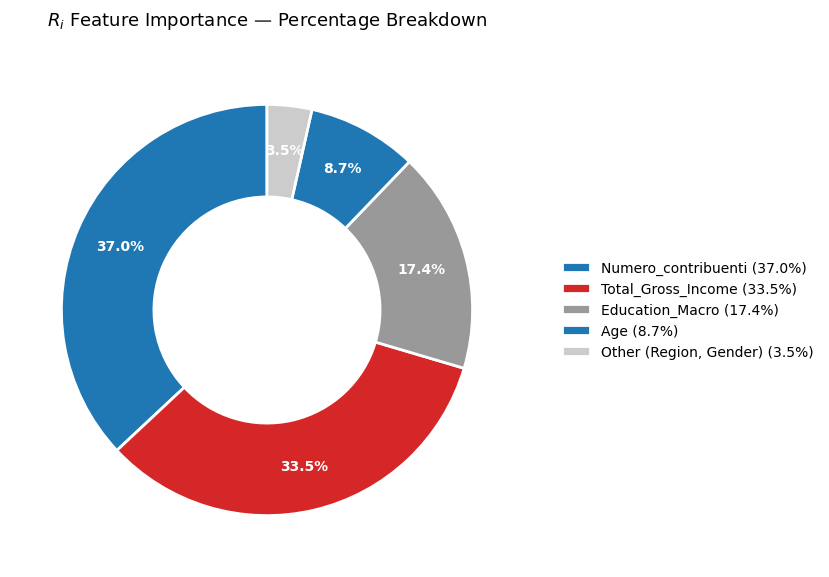

✅ Grafico comunicativo (torta) salvato: ./Materiale/shapley_percentuali_torta_BIS.pdf

Tabella percentuali pronta per il testo:
               feature  percentuale
0  Numero_contribuenti         37.0
1   Total_Gross_Income         33.5
2      Education_Macro         17.4
3                  Age          8.7
4               Region          3.2
5               Gender          0.4


In [2]:
# %% CELL 4quater — grafico comunicativo delle percentuali Shapley
# =============================================================================
# CORRETTO: colori per direzione (coerenti col Grafico 1, non più blu
# uniforme) ed etichette spostate in legenda laterale, per evitare la
# sovrapposizione di testo sulle fette piccole (Gender/Region)
fig3, ax3 = plt.subplots(figsize=(8, 7))

# Per il grafico comunicativo, accorpiamo le variabili sotto il 5% in "Other"
# — Region e Gender restano visibili singolarmente solo nel Grafico 1 (barre),
# qui l'obiettivo è la chiarezza immediata, non l'esaustività
SOGLIA_ALTRO = 0.05
pesi_torta = pesi_ri.sort_values('importance_norm', ascending=False).copy()

principali = pesi_torta[pesi_torta['importance_norm'] >= SOGLIA_ALTRO].copy()
altre = pesi_torta[pesi_torta['importance_norm'] < SOGLIA_ALTRO]

if len(altre) > 0:
    riga_altro = pd.DataFrame({
        'feature': [f"Other ({', '.join(altre['feature'])})"],
        'importance_norm': [altre['importance_norm'].sum()]
    })
    pesi_torta_finale = pd.concat([principali, riga_altro], ignore_index=True)
else:
    pesi_torta_finale = principali

# Colore: 'Other' in grigio neutro (è un accorpamento, non ha una direzione
# unica), le altre feature mantengono il colore per direzione come prima
def colore_per_torta(feat):
    if feat.startswith('Other'):
        return '#cccccc'
    return colori[direzione_nota[feat]]

pesi_torta_finale['colore'] = pesi_torta_finale['feature'].apply(
    lambda f: colore_per_torta(f.split(' (')[0]) if not f.startswith('Other') else '#cccccc'
)

wedges, texts, autotexts = ax3.pie(
    pesi_torta_finale['importance_norm'],
    autopct='%1.1f%%',
    startangle=90,
    colors=pesi_torta_finale['colore'],
    pctdistance=0.78,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2),
    labels=None
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax3.set_title('$R_i$ Feature Importance — Percentage Breakdown', fontsize=13, pad=20)

etichette_legenda = [f"{feat} ({val:.1%})" for feat, val in
                      zip(pesi_torta_finale['feature'], pesi_torta_finale['importance_norm'])]
ax3.legend(wedges, etichette_legenda, loc='center left', bbox_to_anchor=(1.05, 0.5),
           fontsize=10, frameon=False)

plt.tight_layout()

PATH_GRAFICO_TORTA = './Materiale/shapley_percentuali_torta_BIS.pdf'
plt.savefig(PATH_GRAFICO_TORTA, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Grafico comunicativo (torta) salvato: {PATH_GRAFICO_TORTA}")

# Tabella pulita in percentuale arrotondata, utile per il testo del paper
tabella_percentuali = pesi_ri[['feature', 'importance_norm']].copy()
tabella_percentuali['percentuale'] = (tabella_percentuali['importance_norm'] * 100).round(1)
tabella_percentuali = tabella_percentuali[['feature', 'percentuale']].sort_values(
    'percentuale', ascending=False
).reset_index(drop=True)
print("\nTabella percentuali pronta per il testo:")
print(tabella_percentuali)


Tabella percentuali cumulate:
               feature  percentuale  cumulata
0  Numero_contribuenti         37.0      37.0
1   Total_Gross_Income         33.5      70.5
2      Education_Macro         17.4      87.9
3                  Age          8.7      96.6
4               Region          3.2      99.8
5               Gender          0.4     100.2

✅ Tabella salvata: ./Materiale/shapley_percentuali_cumulate_BIS.csv


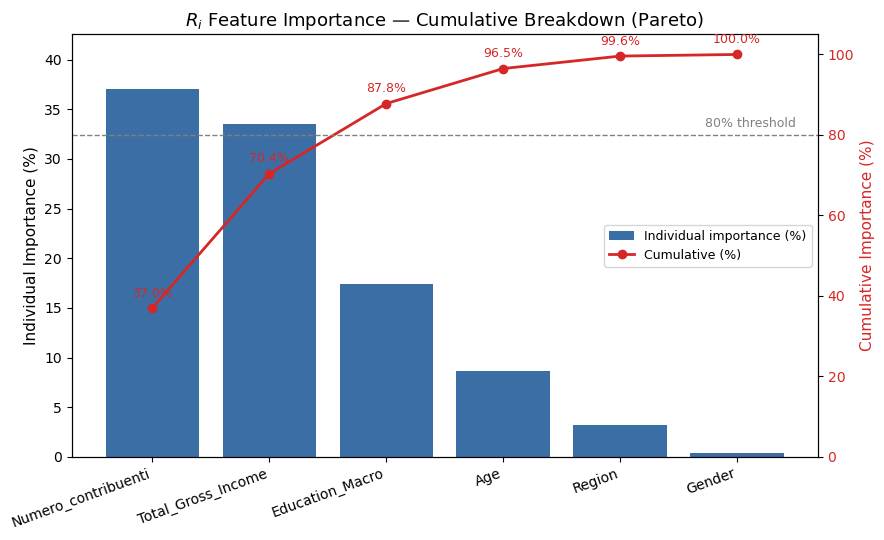

✅ Grafico Pareto salvato: ./Materiale/shapley_cumulata_pareto_BIS.pdf

Tabella percentuali pronta per il testo:
               feature  percentuale
0  Numero_contribuenti         37.0
1   Total_Gross_Income         33.5
2      Education_Macro         17.4
3                  Age          8.7
4               Region          3.2
5               Gender          0.4


In [3]:

# %% CELL 4quinquies — Tabella e grafico delle percentuali CUMULATE (Pareto)
# =============================================================================
# Mostra quante variabili servono per "coprire" la maggior parte
# dell'importanza totale — utile per dire, ad esempio, "le prime 3 variabili
# spiegano già l'88% del rischio".
tabella_cumulata = pesi_ri[['feature', 'importance_norm']].sort_values(
    'importance_norm', ascending=False
).reset_index(drop=True)
tabella_cumulata['percentuale'] = (tabella_cumulata['importance_norm'] * 100).round(1)
tabella_cumulata['cumulata'] = tabella_cumulata['percentuale'].cumsum().round(1)

print("Tabella percentuali cumulate:")
print(tabella_cumulata[['feature', 'percentuale', 'cumulata']])

tabella_cumulata['cumulata'] = tabella_cumulata['importance_norm'].cumsum().mul(100).round(1)

# Salvataggio della tabella come CSV, comoda da allegare o incollare in Word/LaTeX
PATH_TABELLA_CUMULATA = './Materiale/shapley_percentuali_cumulate_BIS.csv'
tabella_cumulata[['feature', 'percentuale', 'cumulata']].to_csv(PATH_TABELLA_CUMULATA, index=False)
print(f"\n✅ Tabella salvata: {PATH_TABELLA_CUMULATA}")

# --- Grafico stile Pareto: barre (importanza singola) + linea (cumulata) ---
fig4, ax_barre = plt.subplots(figsize=(9, 5.5))

ax_barre.bar(tabella_cumulata['feature'], tabella_cumulata['percentuale'],
             color='#3b6ea5', label='Individual importance (%)')
ax_barre.set_ylabel('Individual Importance (%)', fontsize=11)
ax_barre.set_ylim(0, max(tabella_cumulata['percentuale']) * 1.15)
plt.setp(ax_barre.get_xticklabels(), rotation=20, ha='right')

ax_linea = ax_barre.twinx()
ax_linea.plot(tabella_cumulata['feature'], tabella_cumulata['cumulata'],
              color='#d62728', marker='o', linewidth=2, label='Cumulative (%)')
ax_linea.set_ylabel('Cumulative Importance (%)', fontsize=11, color='#d62728')
ax_linea.set_ylim(0, 105)
ax_linea.tick_params(axis='y', labelcolor='#d62728')

# Riga di riferimento all'80% (soglia classica di Pareto)
ax_linea.axhline(80, color='gray', linestyle='--', linewidth=1)
ax_linea.text(len(tabella_cumulata) - 0.5, 82, '80% threshold', fontsize=9,
              color='gray', ha='right')

# Etichette percentuale sui punti della linea cumulata
for i, val in enumerate(tabella_cumulata['cumulata']):
    ax_linea.annotate(f"{val:.1f}%", (i, val), textcoords="offset points",
                       xytext=(0, 8), ha='center', fontsize=9, color='#d62728')

ax_barre.set_title('$R_i$ Feature Importance — Cumulative Breakdown (Pareto)', fontsize=13)

# Legenda unica per entrambi gli assi
linee_1, etichette_1 = ax_barre.get_legend_handles_labels()
linee_2, etichette_2 = ax_linea.get_legend_handles_labels()
ax_barre.legend(linee_1 + linee_2, etichette_1 + etichette_2, loc='center right', fontsize=9)

plt.tight_layout()

PATH_GRAFICO_PARETO = './Materiale/shapley_cumulata_pareto_BIS.pdf'
plt.savefig(PATH_GRAFICO_PARETO, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Grafico Pareto salvato: {PATH_GRAFICO_PARETO}")

# Tabella pulita in percentuale arrotondata, utile per il testo del paper
tabella_percentuali = pesi_ri[['feature', 'importance_norm']].copy()
tabella_percentuali['percentuale'] = (tabella_percentuali['importance_norm'] * 100).round(1)
tabella_percentuali = tabella_percentuali[['feature', 'percentuale']].sort_values(
    'percentuale', ascending=False
).reset_index(drop=True)
print("\nTabella percentuali pronta per il testo:")
print(tabella_percentuali)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Pesi caricati:
               feature  importance_norm
0  Numero_contribuenti         0.369689
1   Total_Gross_Income         0.334552
2      Education_Macro         0.174010
3                  Age         0.086599
4               Region         0.031614
5               Gender         0.003536

Categorie caricate:
  variabile       categoria  shap_medio
0    Region         Abruzzo    0.000002
1    Region      Basilicata    0.000073
2    Region        Calabria   -0.000609
3    Region        Campania    0.000384
4    Region  Emilia-Romagna    0.000254


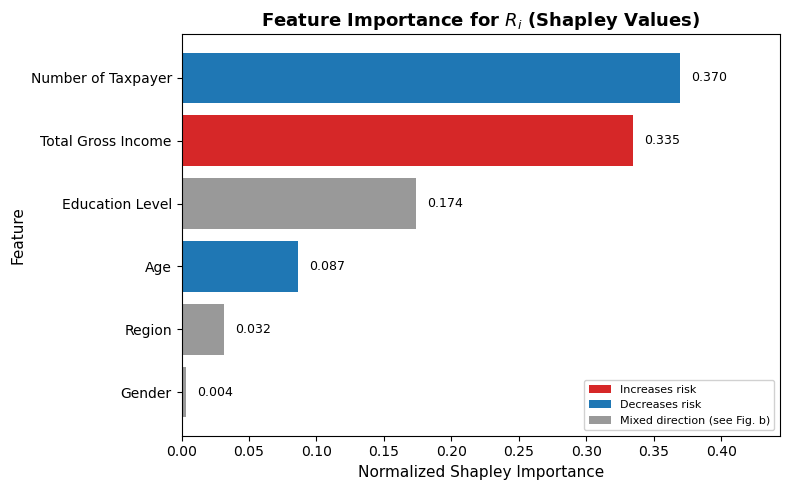

✅ Grafico 1 salvato


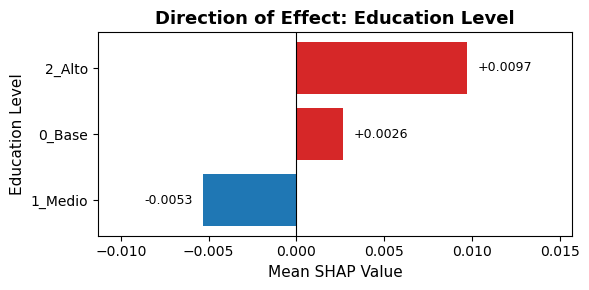

✅ Grafico 2 salvato


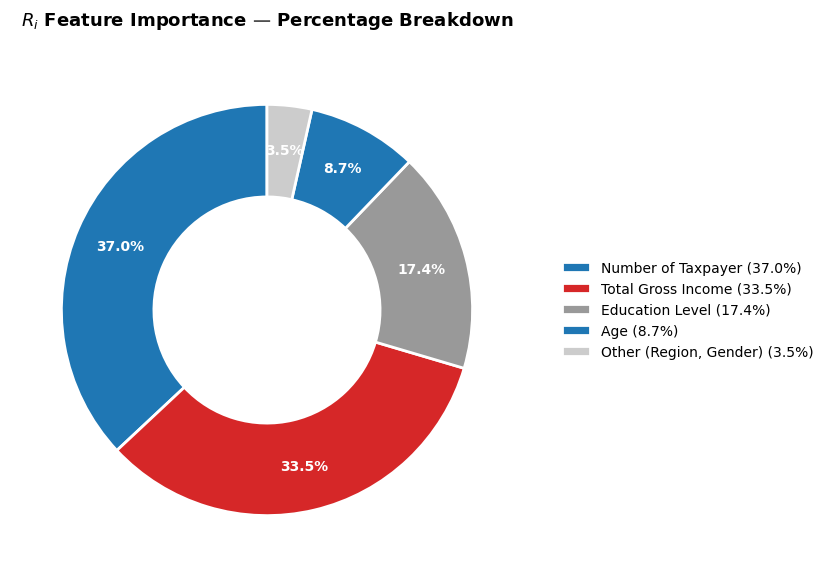

✅ Grafico 3 salvato

Tabella percentuali cumulate:
           feature_en  percentuale  cumulata
0  Number of Taxpayer         37.0      37.0
1  Total Gross Income         33.5      70.4
2     Education Level         17.4      87.8
3                 Age          8.7      96.5
4              Region          3.2      99.6
5              Gender          0.4     100.0
✅ Tabella salvata: ./Materiale/shapley_percentuali_cumulate_BIS.csv


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


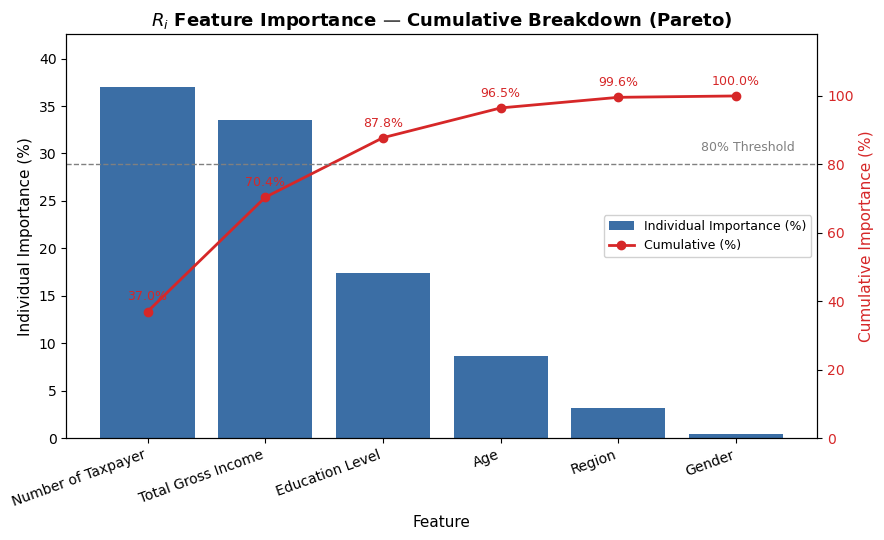

✅ Grafico 4 salvato

🎉 Tutti e 4 i grafici rigenerati senza riaddestrare il modello.


In [4]:
# =============================================================================
# CRI-XAI — SOLO GRAFICI (senza riaddestrare il Random Forest)
# Carica i pesi già salvati da 03BIS invece di ricalcolarli — pochi secondi,
# non i 40 minuti del training completo.
#
# Prerequisito: aver già fatto girare 03BIS almeno una volta, in modo che
# esistano già su Drive:
#   - feature_importances_SHAP_ri_BIS.csv
#   - shap_medio_per_categoria_BIS.csv
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Caricamento dei due file già pronti, invece di ricalcolare ---
PATH_PESI = './Materiale/feature_importances_SHAP_ri_BIS.csv'
PATH_CATEGORIALI = './Materiale/shap_medio_per_categoria_BIS.csv'

pesi_ri = pd.read_csv(PATH_PESI)
df_export_categoriali = pd.read_csv(PATH_CATEGORIALI)

print("Pesi caricati:")
print(pesi_ri)
print("\nCategorie caricate:")
print(df_export_categoriali.head())

# --- Mappatura inglese (identica a quella di 03BIS) ---
ETICHETTE_INGLESI = {
    'Numero_contribuenti': 'Number of Taxpayer',
    'Total_Gross_Income': 'Total Gross Income',
    'Education_Macro': 'Education Level',
    'Age': 'Age',
    'Region': 'Region',
    'Gender': 'Gender',
}

direzione_nota = {
    'Age': 'decrease', 'Total_Gross_Income': 'increase', 'Numero_contribuenti': 'decrease',
    'Region': 'mixed', 'Gender': 'mixed', 'Education_Macro': 'mixed',
}
colori = {'increase': '#d62728', 'decrease': '#1f77b4', 'mixed': '#999999'}


# =============================================================================
# GRAFICO 1 — Barre con importanza + direzione
# =============================================================================
fig, ax = plt.subplots(figsize=(8, 5))
pesi_plot = pesi_ri.sort_values('importance_norm', ascending=True).copy()
pesi_plot['colore'] = pesi_plot['feature'].map(lambda f: colori[direzione_nota[f]])
pesi_plot['feature_en'] = pesi_plot['feature'].map(ETICHETTE_INGLESI)

ax.barh(pesi_plot['feature_en'], pesi_plot['importance_norm'], color=pesi_plot['colore'])
ax.set_xlabel('Normalized Shapley Importance', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
ax.set_title('Feature Importance for $R_i$ (Shapley Values)', fontsize=13, fontweight='bold')
ax.set_xlim(0, max(pesi_plot['importance_norm']) * 1.20)
for i, (feat, val) in enumerate(zip(pesi_plot['feature_en'], pesi_plot['importance_norm'])):
    ax.text(val + 0.008, i, f"{val:.3f}", va='center', fontsize=9)

legend_elements = [
    Patch(facecolor=colori['increase'], label='Increases risk'),
    Patch(facecolor=colori['decrease'], label='Decreases risk'),
    Patch(facecolor=colori['mixed'], label='Mixed direction (see Fig. b)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig('./Materiale/shapley_importance_Ri_BIS.pdf', dpi=300, bbox_inches='tight')
plt.savefig('./Materiale/shapley_importance_Ri_BIS.eps', dpi=300, bbox_inches='tight', format='eps')
plt.show()
print("✅ Grafico 1 salvato")


# =============================================================================
# GRAFICO 2 — Direzione dell'effetto: istruzione
# =============================================================================
edu_data = df_export_categoriali[df_export_categoriali['variabile'] == 'Education_Macro'].copy()
edu_data = edu_data.sort_values('shap_medio')

fig2, ax2 = plt.subplots(figsize=(6, 3))
colori_edu = ['#d62728' if v > 0 else '#1f77b4' for v in edu_data['shap_medio']]
ax2.barh(edu_data['categoria'], edu_data['shap_medio'], color=colori_edu)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Mean SHAP Value', fontsize=11)
ax2.set_ylabel('Education Level', fontsize=11)
ax2.set_title('Direction of Effect: Education Level', fontsize=13, fontweight='bold')
xmin, xmax = edu_data['shap_medio'].min(), edu_data['shap_medio'].max()
padding = (xmax - xmin) * 0.40
ax2.set_xlim(xmin - padding, xmax + padding)
for i, (cat, val) in enumerate(zip(edu_data['categoria'], edu_data['shap_medio'])):
    offset = (xmax - xmin) * 0.04
    x_text = val + offset if val > 0 else val - offset
    ha = 'left' if val > 0 else 'right'
    ax2.text(x_text, i, f"{val:+.4f}", va='center', ha=ha, fontsize=9)
plt.tight_layout()
plt.savefig('./Materiale/shapley_direction_education_BIS.pdf', dpi=300, bbox_inches='tight')
plt.savefig('./Materiale/shapley_direction_education_BIS.eps', dpi=300, bbox_inches='tight', format='eps')
plt.show()
print("✅ Grafico 2 salvato")


# =============================================================================
# GRAFICO 3 — Torta/anello comunicativo
# =============================================================================
fig3, ax3 = plt.subplots(figsize=(8, 7))

SOGLIA_ALTRO = 0.05
pesi_torta = pesi_ri.sort_values('importance_norm', ascending=False).copy()
principali = pesi_torta[pesi_torta['importance_norm'] >= SOGLIA_ALTRO].copy()
altre = pesi_torta[pesi_torta['importance_norm'] < SOGLIA_ALTRO]

if len(altre) > 0:
    nomi_altre_inglese = [ETICHETTE_INGLESI[f] for f in altre['feature']]
    riga_altro = pd.DataFrame({
        'feature': [f"Other ({', '.join(nomi_altre_inglese)})"],
        'importance_norm': [altre['importance_norm'].sum()]
    })
    pesi_torta_finale = pd.concat([principali, riga_altro], ignore_index=True)
else:
    pesi_torta_finale = principali

pesi_torta_finale['feature_display'] = pesi_torta_finale['feature'].apply(
    lambda f: ETICHETTE_INGLESI.get(f, f)
)

def colore_per_torta(feat):
    if feat.startswith('Other'):
        return '#cccccc'
    return colori[direzione_nota[feat]]

pesi_torta_finale['colore'] = pesi_torta_finale['feature'].apply(
    lambda f: colore_per_torta(f.split(' (')[0]) if not f.startswith('Other') else '#cccccc'
)

wedges, texts, autotexts = ax3.pie(
    pesi_torta_finale['importance_norm'],
    autopct='%1.1f%%',
    startangle=90,
    colors=pesi_torta_finale['colore'],
    pctdistance=0.78,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2),
    labels=None
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax3.set_title('$R_i$ Feature Importance — Percentage Breakdown', fontsize=13, fontweight='bold', pad=20)

etichette_legenda = [f"{feat} ({val:.1%})" for feat, val in
                      zip(pesi_torta_finale['feature_display'], pesi_torta_finale['importance_norm'])]
ax3.legend(wedges, etichette_legenda, loc='center left', bbox_to_anchor=(1.05, 0.5),
           fontsize=10, frameon=False)

plt.tight_layout()
plt.savefig('./Materiale/shapley_percentuali_torta_BIS.pdf', dpi=300, bbox_inches='tight')
plt.savefig('./Materiale/shapley_percentuali_torta_BIS.eps', dpi=300, bbox_inches='tight', format='eps')
plt.show()
print("✅ Grafico 3 salvato")


# =============================================================================
# GRAFICO 4 — Pareto (barre + cumulata)
# =============================================================================
tabella_cumulata = pesi_ri[['feature', 'importance_norm']].sort_values(
    'importance_norm', ascending=False
).reset_index(drop=True)
tabella_cumulata['percentuale'] = (tabella_cumulata['importance_norm'] * 100).round(1)
# Cumulata calcolata PRIMA di arrotondare, per evitare lo scarto tipo "100.1%"
tabella_cumulata['cumulata'] = tabella_cumulata['importance_norm'].cumsum().mul(100).round(1)
tabella_cumulata['feature_en'] = tabella_cumulata['feature'].map(ETICHETTE_INGLESI)

print("\nTabella percentuali cumulate:")
print(tabella_cumulata[['feature_en', 'percentuale', 'cumulata']])

PATH_TABELLA_CUMULATA = './Materiale/shapley_percentuali_cumulate_BIS.csv'
tabella_cumulata[['feature_en', 'percentuale', 'cumulata']].rename(
    columns={'feature_en': 'feature'}
).to_csv(PATH_TABELLA_CUMULATA, index=False)
print(f"✅ Tabella salvata: {PATH_TABELLA_CUMULATA}")

fig4, ax_barre = plt.subplots(figsize=(9, 5.5))

ax_barre.bar(tabella_cumulata['feature_en'], tabella_cumulata['percentuale'],
             color='#3b6ea5', label='Individual Importance (%)')
ax_barre.set_xlabel('Feature', fontsize=11)
ax_barre.set_ylabel('Individual Importance (%)', fontsize=11)
ax_barre.set_ylim(0, max(tabella_cumulata['percentuale']) * 1.15)
plt.setp(ax_barre.get_xticklabels(), rotation=20, ha='right')

ax_linea = ax_barre.twinx()
ax_linea.plot(tabella_cumulata['feature_en'], tabella_cumulata['cumulata'],
              color='#d62728', marker='o', linewidth=2, label='Cumulative (%)')
ax_linea.set_ylabel('Cumulative Importance (%)', fontsize=11, color='#d62728')
ax_linea.set_ylim(0, 118)
ax_linea.tick_params(axis='y', labelcolor='#d62728')

ax_linea.axhline(80, color='gray', linestyle='--', linewidth=1)
ax_linea.text(len(tabella_cumulata) - 0.5, 84, '80% Threshold', fontsize=9,
              color='gray', ha='right')

for i, val in enumerate(tabella_cumulata['cumulata']):
    ax_linea.annotate(f"{val:.1f}%", (i, val), textcoords="offset points",
                       xytext=(0, 8), ha='center', fontsize=9, color='#d62728')

ax_barre.set_title('$R_i$ Feature Importance — Cumulative Breakdown (Pareto)',
                    fontsize=13, fontweight='bold')

linee_1, etichette_1 = ax_barre.get_legend_handles_labels()
linee_2, etichette_2 = ax_linea.get_legend_handles_labels()
ax_barre.legend(linee_1 + linee_2, etichette_1 + etichette_2, loc='center right',
                 fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('./Materiale/shapley_cumulata_pareto_BIS.pdf', dpi=300, bbox_inches='tight')
plt.savefig('./Materiale/shapley_cumulata_pareto_BIS.eps', dpi=300, bbox_inches='tight', format='eps')
plt.show()
print("✅ Grafico 4 salvato")

print("\n🎉 Tutti e 4 i grafici rigenerati senza riaddestrare il modello.")

Campione caricato (BIS): 1,174,592 righe
Righe senza corrispondenza comunale: 0 su 1174592
   Comune_Codice    Region Gender  Age Education_Macro  Total_Gross_Income  \
0           1001  Piemonte      M   37         1_Medio        23527.104518   
1           1001  Piemonte      M   85          0_Base         1537.352795   
2           1001  Piemonte      M   84          0_Base        21393.717251   
3           1001  Piemonte      M   62          2_Alto        73219.716790   
4           1001  Piemonte      F   58          2_Alto        84828.509990   

   Numero_contribuenti       r_i  
0                 1963  0.002732  
1                 1963  0.006757  
2                 1963  0.006757  
3                 1963  0.012500  
4                 1963  0.007353  

Distribuzione r_i (BIS):
count    1.174592e+06
mean     2.520394e-02
std      9.145392e-02
min      2.043728e-06
25%      1.355014e-03
50%      3.649635e-03
75%      1.000000e-02
max      1.000000e+00
Name: r_i, dtype: float64
Ca

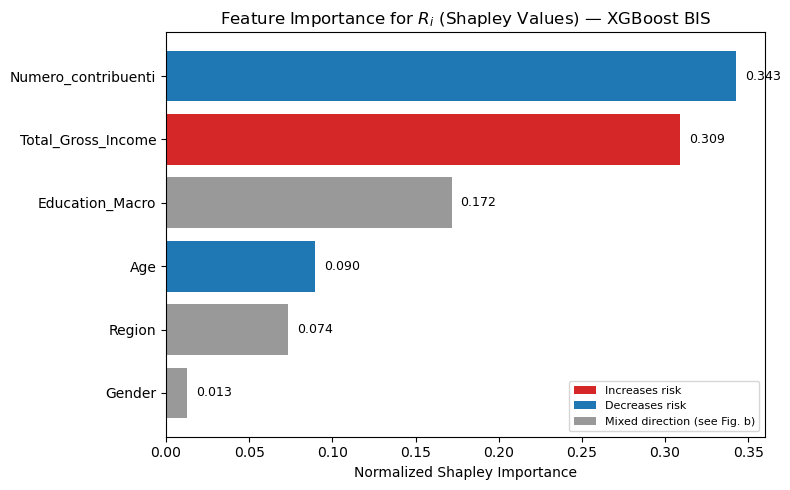

✅ Grafico 1 (XGBoost BIS) salvato


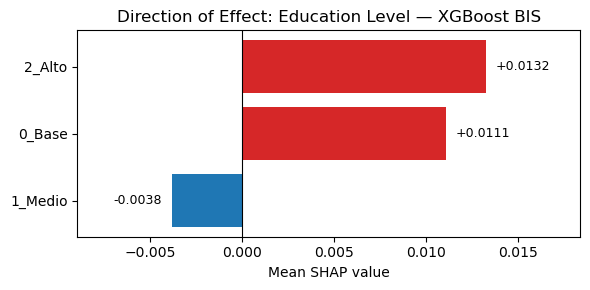

✅ Grafico 2 (XGBoost BIS) salvato


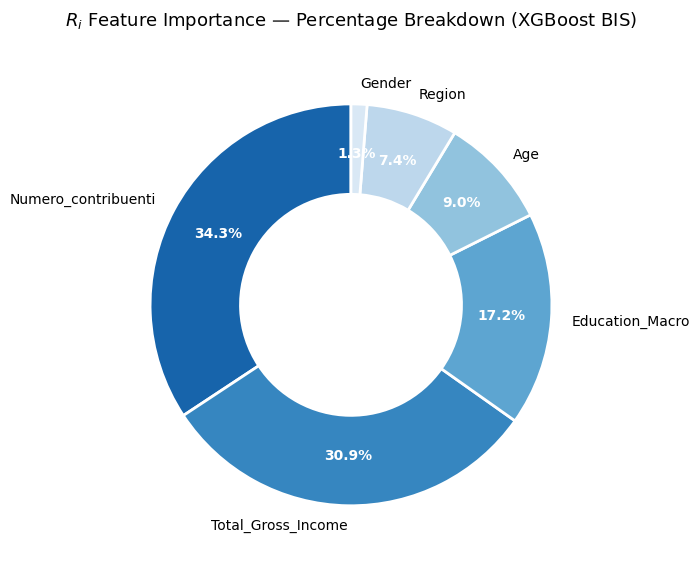

✅ Grafico comunicativo (torta) salvato: ./Materiale/shapley_percentuali_torta_BIS_XGBoost.pdf

Tabella percentuali pronta per il testo:
               feature  percentuale
0  Numero_contribuenti    34.299999
1   Total_Gross_Income    30.900000
2      Education_Macro    17.200001
3                  Age     9.000000
4               Region     7.400000
5               Gender     1.300000
R² del modello di validazione (XGBoost BIS): 0.6384

RGA (XGBoost BIS): 0.9726

RGE (XGBoost BIS):
                          RGE
Numero_contribuenti  0.266469
Total_Gross_Income   0.155233
Age                  0.046387
Education_Macro      0.044459
Region               0.021506
Gender               0.006528

RGF (XGBoost BIS): The RGA-based imparity between the protected gorups is 0.004602685960461206.

RGR (XGBoost BIS):
                          RGR
Gender               0.998653
Region               0.995894
Education_Macro      0.983526
Age                  0.982859
Total_Gross_Income   0.948421
Numero

In [5]:
#### XGBOOST FABIO

# %% CELL 1 — Installazione pacchetti + caricamento dati
# =============================================================================
#!pip install safeaipackage shap catboost xgboost -q

import numpy as np
import pandas as pd
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# CAMBIATO: campione BIS (istruzione condizionata età/genere), da 02BIS
PATH_CAMPIONE = './Materiale/campione_individuale_r_i_BIS.csv'

df = pd.read_csv(PATH_CAMPIONE)

print(f"Campione caricato (BIS): {len(df):,} righe")


# --- Dimensione del comune come feature (INVARIATO da 03) ---
PATH_COMUNI = './Materiale/dataset_random_forest_completo.csv'

df_comuni_size = pd.read_csv(
    PATH_COMUNI,
    sep=None,
    engine='python'
)[['Codice.comune', 'Numero contribuenti']]

df_comuni_size = df_comuni_size.rename(
    columns={
        'Codice.comune': 'Comune_Codice',
        'Numero contribuenti': 'Numero_contribuenti'
    }
)


righe_prima = len(df)

df = df.merge(
    df_comuni_size,
    on='Comune_Codice',
    how='left'
)

righe_senza_match = df['Numero_contribuenti'].isna().sum()

print(
    f"Righe senza corrispondenza comunale: "
    f"{righe_senza_match} su {righe_prima}"
)

if righe_senza_match > 0:

    df = df.dropna(
        subset=['Numero_contribuenti']
    )

    print(
        f"Rimosse — restano {len(df):,} righe"
    )


print(
    df[
        [
            'Comune_Codice',
            'Region',
            'Gender',
            'Age',
            'Education_Macro',
            'Total_Gross_Income',
            'Numero_contribuenti',
            'r_i'
        ]
    ].head()
)

print(
    f"\nDistribuzione r_i (BIS):\n"
    f"{df['r_i'].describe()}"
)


# %% CELL 2 — TEST SU CAMPIONE PICCOLO
# =============================================================================

N_TEST = 20_000

df_test = df.sample(
    N_TEST,
    random_state=RANDOM_STATE
).copy()

print(
    f"Campione di test: "
    f"{len(df_test):,} righe"
)


# %% CELL 3 — Preparazione feature e training del nuovo R_i (BIS)
# =============================================================================

def addestra_e_valuta(
    n_train,
    df_full,
    random_state=42
):

    df_model = df_full.sample(
        min(n_train, len(df_full)),
        random_state=random_state
    ).copy()

    X = pd.get_dummies(
        df_model[
            [
                'Region',
                'Gender',
                'Age',
                'Education_Macro',
                'Total_Gross_Income',
                'Numero_contribuenti'
            ]
        ],
        columns=[
            'Region',
            'Gender',
            'Education_Macro'
        ],
        drop_first=False
    )

    y = df_model['r_i']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=random_state
    )

    # XGBoost al posto di Random Forest
    #
    # base_score viene convertito esplicitamente a float.
    # Questo mantiene il comportamento del modello e impedisce
    # ambiguità con il nuovo formato di XGBoost.

    xgb_model = XGBRegressor(
        n_estimators=300,
        max_depth=12,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=random_state,
        n_jobs=-1,
        objective='reg:squarederror',
        eval_metric='rmse',
        tree_method='hist',
        base_score=float(y_train.mean())
    )

    xgb_model.fit(
        X_train,
        y_train
    )

    y_pred = xgb_model.predict(
        X_test
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    return (
        xgb_model,
        X,
        y,
        X_train,
        X_test,
        y_train,
        y_test,
        y_pred,
        r2
    )


import time


print(
    "Training con N_TRAIN=300.000..."
)

t0 = time.time()

(
    xgb_300k,
    X_300k,
    y_300k,
    X_train_300k,
    X_test_300k,
    y_train_300k,
    y_test_300k,
    y_pred_300k,
    r2_300k
) = addestra_e_valuta(
    300_000,
    df
)

print(
    f"R² con 300k righe: "
    f"{r2_300k:.4f} — "
    f"tempo: {(time.time() - t0) / 60:.1f} minuti"
)


print(
    "\nTraining con N_TRAIN=600.000..."
)

t0 = time.time()

(
    xgb_600k,
    X_600k,
    y_600k,
    X_train_600k,
    X_test_600k,
    y_train_600k,
    y_test_600k,
    y_pred_600k,
    r2_600k
) = addestra_e_valuta(
    600_000,
    df
)

print(
    f"R² con 600k righe: "
    f"{r2_600k:.4f} — "
    f"tempo: {(time.time() - t0) / 60:.1f} minuti"
)


differenza = r2_600k - r2_300k

print(
    f"\nDifferenza di R²: "
    f"{differenza:+.4f}"
)


if abs(differenza) < 0.01:

    print(
        "✅ Differenza trascurabile — resto su 300k."
    )

    (
        xgb_ri,
        X,
        y,
        X_train,
        X_test,
        y_train,
        y_test,
        y_pred
    ) = (
        xgb_300k,
        X_300k,
        y_300k,
        X_train_300k,
        X_test_300k,
        y_train_300k,
        y_test_300k,
        y_pred_300k
    )

    df_model = df.sample(
        300_000,
        random_state=RANDOM_STATE
    ).copy()

else:

    print(
        "⚠️ Differenza non trascurabile — "
        "uso 600k come base definitiva."
    )

    (
        xgb_ri,
        X,
        y,
        X_train,
        X_test,
        y_train,
        y_test,
        y_pred
    ) = (
        xgb_600k,
        X_600k,
        y_600k,
        X_train_600k,
        X_test_600k,
        y_train_600k,
        y_test_600k,
        y_pred_600k
    )

    df_model = df.sample(
        600_000,
        random_state=RANDOM_STATE
    ).copy()


print(
    f"\nR² finale scelto (BIS): "
    f"{r2_score(y_test, y_pred):.4f}"
)

print(
    f"MAE finale (BIS): "
    f"{mean_absolute_error(y_test, y_pred):.6f}"
)


# %% CELL 4 — Pesi Shapley per R_i (BIS)
# =============================================================================
#
# IMPORTANTE:
#
# NON usiamo:
#
#     shap.TreeExplainer(xgb_ri)
#
# perché con XGBoost 3.2.0 + SHAP 0.49.1 può verificarsi:
#
# ValueError: could not convert string to float:
# '[2.5773022E-2]'
#
# Il problema è legato al nuovo formato vettoriale di base_score
# introdotto nelle versioni recenti di XGBoost.
#
# Per evitare qualsiasi modifica alle versioni installate, utilizziamo
# direttamente la predizione SHAP nativa di XGBoost:
#
#     pred_contribs=True
#
# Questa restituisce i contributi TreeSHAP per ogni osservazione.
# L'ultima colonna è il bias/base value e viene esclusa.

import shap

print(
    f"\nSHAP installato: {shap.__version__}"
)

print(
    f"XGBoost installato: {xgb.__version__}"
)


X_shap_sample = X_test.sample(
    min(5000, len(X_test)),
    random_state=RANDOM_STATE
)


# -------------------------------------------------------------------------
# Calcolo dei valori SHAP direttamente tramite XGBoost
# -------------------------------------------------------------------------

X_shap_dmatrix = xgb.DMatrix(
    X_shap_sample,
    feature_names=list(X_shap_sample.columns)
)


shap_contribs = xgb_ri.get_booster().predict(
    X_shap_dmatrix,
    pred_contribs=True
)


# pred_contribs restituisce:
#
# [feature_1, feature_2, ..., feature_n, bias]
#
# L'ultima colonna è il bias e NON è una feature.
#
# Quindi la eliminiamo.

shap_values = shap_contribs[:, :-1]


print(
    f"Dimensione SHAP: "
    f"{shap_values.shape}"
)

print(
    f"Numero feature: "
    f"{X_shap_sample.shape[1]}"
)


# -------------------------------------------------------------------------
# Importanza SHAP
# -------------------------------------------------------------------------

shap_importance = pd.DataFrame(
    {
        'feature_encoded': X_shap_sample.columns,
        'mean_abs_shap': np.abs(
            shap_values
        ).mean(axis=0)
    }
)


def variabile_originale(col):

    for base in [
        'Region',
        'Gender',
        'Education_Macro'
    ]:

        if col.startswith(
            base + '_'
        ):

            return base

    return col


shap_importance['feature'] = (
    shap_importance[
        'feature_encoded'
    ].apply(
        variabile_originale
    )
)


pesi_ri = (
    shap_importance
    .groupby('feature')[
        'mean_abs_shap'
    ]
    .sum()
    .reset_index()
)


pesi_ri['importance_norm'] = (
    pesi_ri['mean_abs_shap']
    /
    pesi_ri['mean_abs_shap'].sum()
)


pesi_ri = pesi_ri.sort_values(
    'importance_norm',
    ascending=False
)


print(
    "Pesi Shapley aggregati per R_i (BIS):"
)

print(
    pesi_ri[
        [
            'feature',
            'importance_norm'
        ]
    ]
)


# CAMBIATO: output con suffisso _BIS_XGBoost

PATH_PESI_OUTPUT = (
    './Materiale/'
    'feature_importances_SHAP_ri_BIS_XGBoost.csv'
)


pesi_ri[
    [
        'feature',
        'importance_norm'
    ]
].to_csv(
    PATH_PESI_OUTPUT,
    index=False
)


print(
    f"\n✅ Salvato: "
    f"{PATH_PESI_OUTPUT}"
)


# %% CELL 4bis — Direzione dell'effetto (segno) — BIS
# =============================================================================

print(
    "=== VARIABILI CONTINUE: "
    "direzione tramite correlazione "
    "feature-valore/SHAP ==="
)


variabili_continue = [
    'Age',
    'Total_Gross_Income',
    'Numero_contribuenti'
]


for var in variabili_continue:

    if var in X_shap_sample.columns:

        corr = np.corrcoef(
            X_shap_sample[var].values,
            shap_values[
                :,
                X_shap_sample.columns.get_loc(var)
            ]
        )[0, 1]

        direzione = (
            "AUMENTA il rischio quando cresce"
            if corr > 0
            else
            "DIMINUISCE il rischio quando cresce"
        )

        print(
            f"{var}: "
            f"correlazione feature/SHAP = "
            f"{corr:+.3f} → "
            f"{direzione}"
        )


print(
    "\n=== VARIABILI CATEGORIALI: "
    "SHAP medio quando la categoria è presente ==="
)


risultati_per_export = []


for base in [
    'Region',
    'Gender',
    'Education_Macro'
]:

    cols_categoria = [
        c
        for c in X_shap_sample.columns
        if c.startswith(base + '_')
    ]

    print(
        f"\n--- {base} ---"
    )

    risultati_categoria = []


    for col in cols_categoria:

        mask = (
            X_shap_sample[col].values == 1
        )

        if mask.sum() > 0:

            shap_medio = (
                shap_values[
                    mask,
                    X_shap_sample.columns.get_loc(col)
                ].mean()
            )

            risultati_categoria.append(
                (
                    col.replace(
                        base + '_',
                        ''
                    ),
                    shap_medio
                )
            )

            risultati_per_export.append(
                {
                    'variabile': base,
                    'categoria': col.replace(
                        base + '_',
                        ''
                    ),
                    'shap_medio': shap_medio
                }
            )


    risultati_categoria.sort(
        key=lambda x: x[1],
        reverse=True
    )


    for (
        nome_categoria,
        shap_medio
    ) in risultati_categoria:

        segno = (
            "aumenta"
            if shap_medio > 0
            else
            "diminuisce"
        )

        print(
            f"  {nome_categoria}: "
            f"SHAP medio = "
            f"{shap_medio:+.5f} "
            f"({segno} il rischio)"
        )


df_export_categoriali = pd.DataFrame(
    risultati_per_export
)


PATH_CATEGORIALI = (
    './Materiale/'
    'shap_medio_per_categoria_BIS_XGBoost.csv'
)


df_export_categoriali.to_csv(
    PATH_CATEGORIALI,
    index=False
)


print(
    f"\n✅ Salvato: "
    f"{PATH_CATEGORIALI}"
)


# %% CELL 4ter — Grafico dei pesi Shapley,
#              con direzione dell'effetto (BIS)
# =============================================================================

import matplotlib.pyplot as plt


direzione_nota = {

    'Age': 'decrease',

    'Total_Gross_Income': 'increase',

    'Numero_contribuenti': 'decrease',

    'Region': 'mixed',

    'Gender': 'mixed',

    'Education_Macro': 'mixed'
}


colori = {

    'increase': '#d62728',

    'decrease': '#1f77b4',

    'mixed': '#999999'
}


fig, ax = plt.subplots(
    figsize=(8, 5)
)


pesi_plot = pesi_ri.sort_values(
    'importance_norm',
    ascending=True
).copy()


pesi_plot['colore'] = (
    pesi_plot['feature'].map(
        lambda f:
        colori[direzione_nota[f]]
    )
)


ax.barh(
    pesi_plot['feature'],
    pesi_plot['importance_norm'],
    color=pesi_plot['colore']
)


ax.set_xlabel(
    'Normalized Shapley Importance'
)


ax.set_title(
    'Feature Importance for $R_i$ '
    '(Shapley Values) — XGBoost BIS'
)


for i, (
    feat,
    val
) in enumerate(
    zip(
        pesi_plot['feature'],
        pesi_plot['importance_norm']
    )
):

    ax.text(
        val + 0.005,
        i,
        f"{val:.3f}",
        va='center',
        fontsize=9
    )


from matplotlib.patches import Patch


legend_elements = [

    Patch(
        facecolor=colori['increase'],
        label='Increases risk'
    ),

    Patch(
        facecolor=colori['decrease'],
        label='Decreases risk'
    ),

    Patch(
        facecolor=colori['mixed'],
        label='Mixed direction (see Fig. b)'
    )
]


ax.legend(
    handles=legend_elements,
    loc='lower right',
    fontsize=8
)


plt.tight_layout()


plt.savefig(
    './Materiale/'
    'shapley_importance_Ri_BIS_XGBoost.pdf',
    dpi=300,
    bbox_inches='tight'
)


plt.show()


print(
    "✅ Grafico 1 (XGBoost BIS) salvato"
)


# -------------------------------------------------------------------------
# Grafico Education
# -------------------------------------------------------------------------

edu_data = df_export_categoriali[
    df_export_categoriali['variabile']
    == 'Education_Macro'
].copy()


edu_data = edu_data.sort_values(
    'shap_medio'
)


fig2, ax2 = plt.subplots(
    figsize=(6, 3)
)


colori_edu = [

    '#d62728'
    if v > 0
    else '#1f77b4'

    for v in edu_data['shap_medio']
]


ax2.barh(
    edu_data['categoria'],
    edu_data['shap_medio'],
    color=colori_edu
)


ax2.axvline(
    0,
    color='black',
    linewidth=0.8
)


ax2.set_xlabel(
    'Mean SHAP value'
)


ax2.set_title(
    'Direction of Effect: '
    'Education Level — XGBoost BIS'
)


xmin, xmax = (
    edu_data['shap_medio'].min(),
    edu_data['shap_medio'].max()
)


padding = (
    xmax - xmin
) * 0.30


ax2.set_xlim(
    xmin - padding,
    xmax + padding
)


for i, (
    cat,
    val
) in enumerate(
    zip(
        edu_data['categoria'],
        edu_data['shap_medio']
    )
):

    offset = (
        xmax - xmin
    ) * 0.03


    x_text = (
        val + offset
        if val > 0
        else val - offset
    )


    ha = (
        'left'
        if val > 0
        else 'right'
    )


    ax2.text(
        x_text,
        i,
        f"{val:+.4f}",
        va='center',
        ha=ha,
        fontsize=9
    )


plt.tight_layout()


plt.savefig(
    './Materiale/'
    'shapley_direction_education_BIS_XGBoost.pdf',
    dpi=300,
    bbox_inches='tight'
)


plt.show()


print(
    "✅ Grafico 2 (XGBoost BIS) salvato"
)


# %% CELL 4quater — NUOVO:
#              grafico comunicativo delle percentuali Shapley
# =============================================================================
#
# Un grafico più immediato da leggere per un pubblico non tecnico
# (o per l'apertura della Sezione Risultati).
#
# A torta/anello, con le percentuali scritte direttamente sulle fette.
# Complementa il Grafico 1, più tecnico, con la direzione dell'effetto.
# =============================================================================


fig3, ax3 = plt.subplots(
    figsize=(7, 7)
)


pesi_torta = pesi_ri.sort_values(
    'importance_norm',
    ascending=False
).copy()


colori_torta = plt.cm.Blues_r(
    np.linspace(
        0.2,
        0.85,
        len(pesi_torta)
    )
)


wedges, texts, autotexts = ax3.pie(

    pesi_torta['importance_norm'],

    labels=pesi_torta['feature'],

    autopct='%1.1f%%',

    startangle=90,

    colors=colori_torta,

    pctdistance=0.75,

    wedgeprops=dict(
        width=0.45,
        edgecolor='white',
        linewidth=2
    )
)


for autotext in autotexts:

    autotext.set_color(
        'white'
    )

    autotext.set_fontweight(
        'bold'
    )

    autotext.set_fontsize(
        10
    )


for text in texts:

    text.set_fontsize(
        10
    )


ax3.set_title(
    '$R_i$ Feature Importance — '
    'Percentage Breakdown (XGBoost BIS)',
    fontsize=13,
    pad=20
)


plt.tight_layout()


PATH_GRAFICO_TORTA = (
    './Materiale/'
    'shapley_percentuali_torta_BIS_XGBoost.pdf'
)


plt.savefig(
    PATH_GRAFICO_TORTA,
    dpi=300,
    bbox_inches='tight'
)


plt.show()


print(
    f"✅ Grafico comunicativo (torta) salvato: "
    f"{PATH_GRAFICO_TORTA}"
)


# -------------------------------------------------------------------------
# Tabella pulita in percentuale arrotondata,
# utile per il testo del paper
# -------------------------------------------------------------------------

tabella_percentuali = pesi_ri[
    [
        'feature',
        'importance_norm'
    ]
].copy()


tabella_percentuali['percentuale'] = (
    tabella_percentuali['importance_norm']
    * 100
).round(1)


tabella_percentuali = tabella_percentuali[
    [
        'feature',
        'percentuale'
    ]
].sort_values(
    'percentuale',
    ascending=False
).reset_index(
    drop=True
)


print(
    "\nTabella percentuali pronta per il testo:"
)

print(
    tabella_percentuali
)


# %% CELL 5 — Validazione SAFE AI con il PACCHETTO UFFICIALE (BIS)
# =============================================================================

from sklearn.preprocessing import OrdinalEncoder


X_cat = df_model[
    [
        'Region',
        'Gender',
        'Age',
        'Education_Macro',
        'Total_Gross_Income',
        'Numero_contribuenti'
    ]
].copy()


oe = OrdinalEncoder()


X_cat[
    [
        'Region',
        'Gender',
        'Education_Macro'
    ]
] = oe.fit_transform(
    X_cat[
        [
            'Region',
            'Gender',
            'Education_Macro'
        ]
    ]
).astype(int)


for col in [
    'Region',
    'Gender',
    'Education_Macro'
]:

    X_cat[col] = X_cat[
        col
    ].astype('category')


X_train_cat, X_test_cat, y_train_cat, y_test_cat = (
    train_test_split(
        X_cat,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE
    )
)


# XGBoost al posto di Random Forest

xgb_ri_cat = XGBRegressor(

    n_estimators=300,

    max_depth=12,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=RANDOM_STATE,

    n_jobs=-1,

    objective='reg:squarederror',

    eval_metric='rmse',

    tree_method='hist',

    base_score=float(
        y_train_cat.mean()
    )
)


xgb_ri_cat.fit(

    X_train_cat.astype(
        {
            c: 'int'
            for c in [
                'Region',
                'Gender',
                'Education_Macro'
            ]
        }
    ),

    y_train_cat
)


y_pred_cat = xgb_ri_cat.predict(

    X_test_cat.astype(
        {
            c: 'int'
            for c in [
                'Region',
                'Gender',
                'Education_Macro'
            ]
        }
    )
)


print(
    f"R² del modello di validazione "
    f"(XGBoost BIS): "
    f"{r2_score(y_test_cat, y_pred_cat):.4f}"
)


from sklearn.base import (
    BaseEstimator,
    RegressorMixin
)


class ModelloConCastAutomatico(
    RegressorMixin,
    BaseEstimator
):

    def __init__(
        self,
        modello,
        colonne_categoriali
    ):

        self.modello = modello

        self.colonne_categoriali = (
            colonne_categoriali
        )


    def predict(
        self,
        X
    ):

        X_safe = X.copy()

        for c in self.colonne_categoriali:

            if c in X_safe.columns:

                X_safe[c] = (
                    X_safe[c].astype(int)
                )

        return self.modello.predict(
            X_safe
        )


    def predict_proba(
        self,
        X
    ):

        X_safe = X.copy()

        for c in self.colonne_categoriali:

            if c in X_safe.columns:

                X_safe[c] = (
                    X_safe[c].astype(int)
                )

        return self.modello.predict_proba(
            X_safe
        )


xgb_ri_cat_safe = (
    ModelloConCastAutomatico(
        xgb_ri_cat,
        [
            'Region',
            'Gender',
            'Education_Macro'
        ]
    )
)


from safeaipackage.core import rga

from safeaipackage.check_explainability import (
    compute_rge_values
)

from safeaipackage.check_fairness import (
    compute_rga_parity
)

from safeaipackage.check_robustness import (
    compute_rgr_values
)


variabili_cat = [

    'Region',

    'Gender',

    'Age',

    'Education_Macro',

    'Total_Gross_Income',

    'Number of taxpayers'
]


# -------------------------------------------------------------------------
# RGA
# -------------------------------------------------------------------------

rga_score = rga(
    y_test_cat.values,
    y_pred_cat
)


print(
    f"\nRGA (XGBoost BIS): "
    f"{rga_score:.4f}"
)


# -------------------------------------------------------------------------
# RGE
# -------------------------------------------------------------------------

rge_values = compute_rge_values(

    xtrain=X_train_cat,

    xtest=X_test_cat,

    yhat=y_pred_cat,

    model=xgb_ri_cat_safe,

    variables=variabili_cat,

    group=False
)


print(
    "\nRGE (XGBoost BIS):"
)

print(
    rge_values
)


# -------------------------------------------------------------------------
# RGF
# -------------------------------------------------------------------------

rgf_score = compute_rga_parity(

    xtrain=X_train_cat,

    xtest=X_test_cat,

    ytest=y_test_cat,

    yhat=y_pred_cat,

    model=xgb_ri_cat_safe,

    protectedvariable='Gender'
)


print(
    f"\nRGF (XGBoost BIS): "
    f"{rgf_score}"
)


# -------------------------------------------------------------------------
# RGR
# -------------------------------------------------------------------------

rgr_values = compute_rgr_values(

    xtest=X_test_cat,

    yhat=y_pred_cat,

    model=xgb_ri_cat_safe,

    variables=variabili_cat,

    perturbation_percentage=0.05,

    group=False
)


print(
    "\nRGR (XGBoost BIS):"
)

print(
    rgr_values
)


print(
    "\n✅ Validazione SAFE AI "
    "(XGBoost BIS) completata."
)